In [132]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [133]:
house_data=pd.read_csv(r"data/HousePricePrediction.csv")

In [134]:
print(house_data)

        Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0        0          60       RL     8450    Inside     1Fam            5   
1        1          20       RL     9600       FR2     1Fam            8   
2        2          60       RL    11250    Inside     1Fam            5   
3        3          70       RL     9550    Corner     1Fam            5   
4        4          60       RL    14260       FR2     1Fam            5   
...    ...         ...      ...      ...       ...      ...          ...   
2914  2914         160       RM     1936    Inside    Twnhs            7   
2915  2915         160       RM     1894    Inside   TwnhsE            5   
2916  2916          20       RL    20000    Inside     1Fam            7   
2917  2917          85       RL    10441    Inside     1Fam            5   
2918  2918          60       RL     9627    Inside     1Fam            5   

      YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0      

In [135]:
house_data.head(10)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0


In [136]:
house_data.tail()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN
2918,2918,60,RL,9627,Inside,1Fam,5,1993,1994,HdBoard,0.0,996.0,NaN


<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

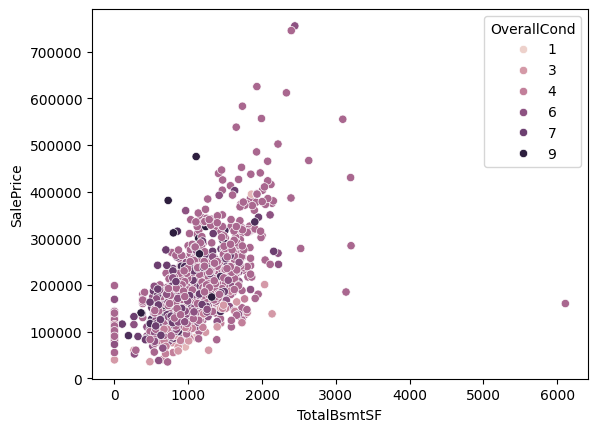

In [137]:
sns.scatterplot( x= house_data["TotalBsmtSF"], y= house_data["SalePrice"], hue= house_data["OverallCond"])

<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

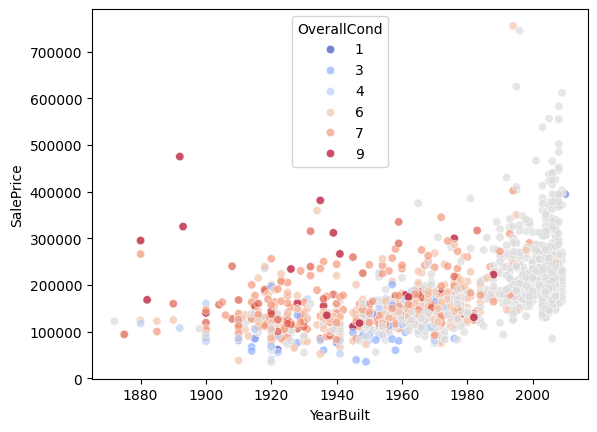

In [138]:
sns.scatterplot(
    data=house_data,
    x='YearBuilt',
    y='SalePrice',
    hue='OverallCond',
    palette='coolwarm',
    alpha=0.7
)

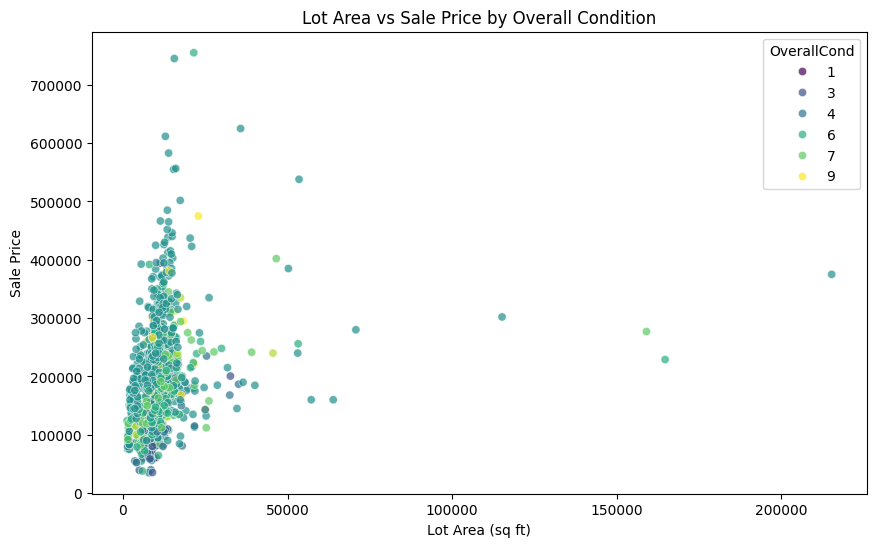

In [139]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=house_data,
    x='LotArea',
    y='SalePrice',
    hue='OverallCond',
    palette='viridis',
    alpha=0.7
)

plt.title('Lot Area vs Sale Price by Overall Condition')
plt.xlabel('Lot Area (sq ft)')
plt.ylabel('Sale Price')
plt.show()

In [140]:
house_data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [141]:
house_data.shape

(2919, 13)

In [142]:
house_data["SalePrice"]=house_data["SalePrice"].fillna(house_data["SalePrice"].mean())

house_data.drop(["Id"] , axis=1, inplace = True)

house_data=house_data.dropna()

In [143]:
house_data.isna().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [144]:

cols =["MSZoning", "LotConfig", "BldgType", "Exterior1st"]
house_data = pd.get_dummies(house_data, columns=cols , drop_first= True , dtype=int)

In [145]:
house_data.head()


,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_FV,MSZoning_RH,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,2003,0.0,856.0,208500.0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,20,9600,8,1976,1976,0.0,1262.0,181500.0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,60,11250,5,2001,2002,0.0,920.0,223500.0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,70,9550,5,1915,1970,0.0,756.0,140000.0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,60,14260,5,2000,2000,0.0,1145.0,250000.0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [146]:
x=house_data.drop(["SalePrice"], axis=1)
y=house_data["SalePrice"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0)

In [147]:
print(y_train.head())
print(y_train.dtype)
print(type(y_train))

1453     84500.00000
2021    180921.19589
188     153337.00000
1273    177000.00000
1960    180921.19589
Name: SalePrice, dtype: float64
float64
<class 'pandas.core.series.Series'>


In [148]:
x_train.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
1453,20,17217,5,2006,2006,0.0,1140.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2021,20,19508,5,1974,1974,0.0,1430.0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
188,90,7018,5,1979,1979,0.0,1086.0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1273,80,11512,7,1959,2006,0.0,1019.0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1960,20,7560,5,1971,1971,613.0,864.0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


In [149]:
y_test.head()

1728    180921.19589
2689    180921.19589
1151    149900.00000
2762    180921.19589
1180    250000.00000
Name: SalePrice, dtype: float64

In [150]:
model = LinearRegression()
model.fit(x_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [151]:
y_pred=model.predict(x_test)

In [152]:
print(y_pred)

[191650.15923449 256694.21204008 172701.86041706 178271.40635751
 206419.73613526 197732.89101834 122841.48375805 157878.58934738
 191291.77887932 204804.03308353 150243.64027564 219384.08152954
 175255.50575308 146897.11420032 199206.87801954 140385.69033295
 168183.44447516 163859.73646194 199489.97467243 197189.64221706
 196128.98519652 133933.9044786  213384.66385958 171491.85738482
 134813.81633663 155413.33744835 147306.70226195 172544.46498721
 162993.16873967 149133.18652125 165985.90539426 190830.5097074
 163121.19310168 194180.0272962  173858.91795552 196437.34882538
 141050.11569808 164048.62478896 170097.87353521 168791.86980326
 213867.76779934 227566.00767484 225968.66607709 141556.62431201
 200123.25857303 221255.82922142 219628.05092849 112066.64524959
 170881.54038786 195695.22225925 199297.32301991 194250.64094596
 125567.52706621 153150.46411961 197129.20194131 152353.39846162
 135830.20477894 222158.33887991 182830.5698671  199591.81857295
 206995.28102922 167071.63

In [153]:
r2_score = r2_score(y_test, y_pred)

In [154]:
print(r2_score)

0.374142179613842


In [155]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np


In [156]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(mean_absolute_percentage_error(y_test, y_pred))

MAE: 30829.936664322024
RMSE: 41138.558702301416
0.18742025463427914


In [157]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

x = house_data.drop("SalePrice", axis=1)
y = house_data["SalePrice"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LinearRegression()

model.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [160]:


y_pred = model.predict(x_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(mean_absolute_percentage_error(y_test, y_pred))


R2 Score: 0.3741421796138533
MAE: 30829.936664321856
RMSE: 41138.558702301045
0.18742025463427794
